In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
import tensorflow.keras as keras
import keras.layers as layers
import keras.models as models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud

from nltk.tokenize import TweetTokenizer # TweetTokenizer handles apostrophes and contractions better than word_tokenize for our use case
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords

In [ ]:
# configure pandas ouput to show all columns and full text
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Load Dataset
data = pd.read_csv('EN_FR_data.tsv', sep='\t')
data.columns = ['EN_Sent_ID','English', 'FR_Sent_ID','French']

In [ ]:
# reduce data size to 20000 rows for feasibility of training
data = data.head(20000)

In [ ]:
data

,EN_Sent_ID,English,FR_Sent_ID,French
0,1276,Let's try something.,456963,Tentons quelque chose !
1,1277,I have to go to sleep.,373908,Je dois aller dormir.
2,1280,Today is June 18th and it is Muiriel's birthday!,3095,Aujourd'hui nous sommes le 18 juin et c'est l'anniversaire de Muiriel !
3,1280,Today is June 18th and it is Muiriel's birthday!,696081,"Aujourd'hui c'est le 18 juin, et c'est l'anniversaire de Muiriel."
4,1282,Muiriel is 20 now.,3097,Muiriel a 20 ans maintenant.
...,...,...,...,...
19995,55846,This is the letter written by Mr Brown.,344270,C'est la lettre écrite par M. Brown.
19996,55848,This is a kind of bread.,748143,C'est une sorte de pain.
19997,55851,What an interesting book this is!,1050969,Quel livre intéressant !
19998,55858,What a big book this is!,1967938,Quel gros livre !


In [ ]:
# preprocess text function
# perform lowercasing and remove punctuation that is not part of a word
def preprocess(text):
    pre_text = [word for word in TweetTokenizer().tokenize(text.lower()) if word.isalpha() or len(word) > 1]
    return " ".join(pre_text)

In [ ]:
# Apply preprocessing to both English and French columns and save to new dataframe
df_clean = data.copy()
df_clean['English'] = df_clean['English'].apply(preprocess)
df_clean['French'] = df_clean['French'].apply(preprocess)

In [ ]:
df_clean

,EN_Sent_ID,English,FR_Sent_ID,French
0,1276,let's try something,456963,tentons quelque chose
1,1277,i have to go to sleep,373908,je dois aller dormir
2,1280,today is june 18th and it is muiriel's birthday,3095,aujourd'hui nous sommes le 18 juin et c'est l'anniversaire de muiriel
3,1280,today is june 18th and it is muiriel's birthday,696081,aujourd'hui c'est le 18 juin et c'est l'anniversaire de muiriel
4,1282,muiriel is 20 now,3097,muiriel a 20 ans maintenant
...,...,...,...,...
19995,55846,this is the letter written by mr brown,344270,c'est la lettre écrite par m brown
19996,55848,this is a kind of bread,748143,c'est une sorte de pain
19997,55851,what an interesting book this is,1050969,quel livre intéressant
19998,55858,what a big book this is,1967938,quel gros livre


In [ ]:
# save cleaned data to new csv file
df_clean.to_csv("cleaned_data.csv", index=False, encoding='utf-8-sig')

Text(0.5, 1.0, 'French Word Cloud')

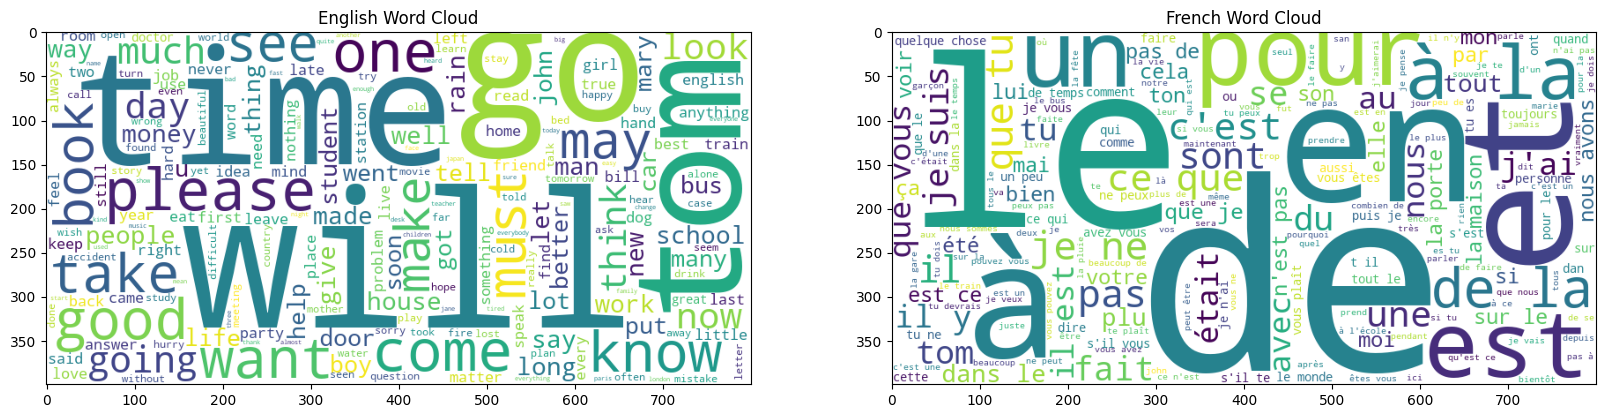

In [ ]:
# visualize word frequency using wordclouds
english_text = " ".join(df_clean['English'])
french_text = " ".join(df_clean['French'])

english_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(english_text)
french_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(french_text)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(english_wordcloud)
plt.title('English Word Cloud')

plt.subplot(1, 2, 2)
plt.imshow(french_wordcloud)
plt.title('French Word Cloud')

In [ ]:
# convert dataframe to suitable format for training
# english and french sentences under one column with class labels
df_en = pd.DataFrame({
    "text": df_clean["English"],
    "label": "EN"
})

df_fr = pd.DataFrame({
    "text": df_clean["French"],
    "label": "FR"
})

df_train = pd.concat([df_en, df_fr]).sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
df_train

,text,label
0,tom ne sait pas nager en revanche il est bon au baseball,FR
1,the doctor examined over fifty patients that day,EN
2,médicalement parlant je vous recommande de perdre du poids,FR
3,some boats are on the lake,EN
4,de quoi parlions-nous,FR
...,...,...
39995,all we need now is action not discussion,EN
39996,france seems to be swinging left britain to the right,EN
39997,je suis arrivé là-bas trop tôt,FR
39998,i won't lose,EN


In [ ]:
# define x and y for training
x= df_train['text']
y = df_train['label']

In [ ]:
# define function to convert sentence labels to token labels for token-level classification (needed for multilabel token classification)
def sentence_to_token_labels(sentences, labels):
    x_tokens = []
    y_tokens = []

    for sent, label in zip(sentences, labels):
        # white space split is enough as text is already preprocessed
        words = sent.split()

        x_tokens.append(words)
        y_tokens.append([label] * len(words))  # repeat sentence label for each token in the sentence (convert to word/token level labels)

    return x_tokens, y_tokens

In [ ]:
# use function to get token-level labels for training
x_tokens, y_tokens = sentence_to_token_labels(x, y)

In [ ]:
df_train["x_tokens"] = x_tokens
df_train["y_tokens"] = y_tokens
df_train

,text,label,x_tokens,y_tokens
0,tom ne sait pas nager en revanche il est bon au baseball,FR,"[tom, ne, sait, pas, nager, en, revanche, il, est, bon, au, baseball]","[FR, FR, FR, FR, FR, FR, FR, FR, FR, FR, FR, FR]"
1,the doctor examined over fifty patients that day,EN,"[the, doctor, examined, over, fifty, patients, that, day]","[EN, EN, EN, EN, EN, EN, EN, EN]"
2,médicalement parlant je vous recommande de perdre du poids,FR,"[médicalement, parlant, je, vous, recommande, de, perdre, du, poids]","[FR, FR, FR, FR, FR, FR, FR, FR, FR]"
3,some boats are on the lake,EN,"[some, boats, are, on, the, lake]","[EN, EN, EN, EN, EN, EN]"
4,de quoi parlions-nous,FR,"[de, quoi, parlions-nous]","[FR, FR, FR]"
...,...,...,...,...
39995,all we need now is action not discussion,EN,"[all, we, need, now, is, action, not, discussion]","[EN, EN, EN, EN, EN, EN, EN, EN]"
39996,france seems to be swinging left britain to the right,EN,"[france, seems, to, be, swinging, left, britain, to, the, right]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]"
39997,je suis arrivé là-bas trop tôt,FR,"[je, suis, arrivé, là-bas, trop, tôt]","[FR, FR, FR, FR, FR, FR]"
39998,i won't lose,EN,"[i, won't, lose]","[EN, EN, EN]"


In [ ]:
# save training data to new csv file
df_train.drop(['text', 'label'], axis=1).to_csv("training_data.csv", index=False, encoding='utf-8-sig')

In [ ]:
# get max sentence length stats to help determine max_len for padding
lengths = df_train["x_tokens"].apply(len)

print("Max length:", lengths.max())
print("Min length:", lengths.min())
print("Mean length:", lengths.mean())
print("Median length:", lengths.median())
print("95 percentile length:", lengths.quantile(0.95))

Max length: 69
Min length: 1
Mean length: 7.3164
Median length: 7.0
95 percentile length: 13.0


In [ ]:
Q1 = lengths.quantile(0.25)
Q3 = lengths.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -1.0
Upper bound: 15.0


In [ ]:
outliers = df_train[(lengths < lower_bound) | (lengths > upper_bound)]

print("Number of outlier sentences:", len(outliers))
outliers[["x_tokens"]].head()

Number of outlier sentences: 894


,x_tokens
31,"[tu, auras, beau, étudier, de, toutes, tes, forces, tu, n'arriveras, pas, à, maîtriser, l'anglais, en, un, an, ou, deux]"
34,"[ray, était, prêt, à, corroborer, l'histoire, de, gary, mais, la, police, n'était, toujours, pas, convaincue, que, l'un, d'eux, dise, la, vérité]"
96,"[she, was, very, shy, about, her, emergency, problem, and, asked, the, gynecologist, to, please, examine, her]"
130,"[that, would, be, twenty-seven, words, instead, of, four, and, while, the, bare, message, of, the, longer, statement, would, be, understood, the, persuasive, force, would, be, lost]"
132,"[as, i, missed, the, train, i, had, to, wait, for, the, next, one, for, about, an, hour]"


In [ ]:
# define max sentence length as 95 percentile since outliers are present with much higher lengths than the rest of the data
max_len = int(lengths.quantile(0.95))
max_len

13

In [ ]:
# apply label encoding to class labels using manual labels
labels = {
    "PAD": 0,
    "EN": 1,
    "FR": 2
}

# number of classes is 3 (PAD, EN, FR)
num_classes = len(labels)

def encode_labels(label_sequences):
    # for each sequence of language tags, convert each tag to its corresponding integer label using the labels dictionary
    # then pad the sentences to ensure uniform length
    encoded = [[labels[tag] for tag in seq] for seq in label_sequences]
    return pad_sequences(encoded, maxlen=max_len, padding='post')

y_enc = encode_labels(y_tokens)

In [ ]:
print(y_enc.shape)
print(type(y_enc))

(40000, 13)
<class 'numpy.ndarray'>


In [ ]:
df_train["y_enc"] = list(y_enc)
df_train

,text,label,x_tokens,y_tokens,y_enc
0,tom ne sait pas nager en revanche il est bon au baseball,FR,"[tom, ne, sait, pas, nager, en, revanche, il, est, bon, au, baseball]","[FR, FR, FR, FR, FR, FR, FR, FR, FR, FR, FR, FR]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0]"
1,the doctor examined over fifty patients that day,EN,"[the, doctor, examined, over, fifty, patients, that, day]","[EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]"
2,médicalement parlant je vous recommande de perdre du poids,FR,"[médicalement, parlant, je, vous, recommande, de, perdre, du, poids]","[FR, FR, FR, FR, FR, FR, FR, FR, FR]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0]"
3,some boats are on the lake,EN,"[some, boats, are, on, the, lake]","[EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]"
4,de quoi parlions-nous,FR,"[de, quoi, parlions-nous]","[FR, FR, FR]","[2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
39995,all we need now is action not discussion,EN,"[all, we, need, now, is, action, not, discussion]","[EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]"
39996,france seems to be swinging left britain to the right,EN,"[france, seems, to, be, swinging, left, britain, to, the, right]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]"
39997,je suis arrivé là-bas trop tôt,FR,"[je, suis, arrivé, là-bas, trop, tôt]","[FR, FR, FR, FR, FR, FR]","[2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0]"
39998,i won't lose,EN,"[i, won't, lose]","[EN, EN, EN]","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [ ]:
# perform vectorization for x using Keras Tokenizer and pad sequences to ensure uniform input length

# recreate x into String format for tokenization since Keras Tokenizer expects text input
x_flat = [" ".join(tokens) for tokens in x_tokens]

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(x_flat)

# convert text to sequences of integers based on the fitted tokenizer
x_seq = tokenizer.texts_to_sequences(x_flat)

# pad sequences to ensure uniform input length
x_pad = pad_sequences(x_seq, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [ ]:
# split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_pad, y_enc, train_size=0.8, random_state=42)

In [ ]:
model = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len,
        mask_zero=True   # tells model to ignore padding (0)
    ),

    layers.SimpleRNN(64, 
                     return_sequences=True), # we need sequences output for token-level classification

    layers.TimeDistributed(layers.Dense(num_classes, activation="softmax"))
])

m:\dlproject\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# set sample weights to 0 for padding tokens (label 0) and 1 for non-padding tokens to prevent model from learning from padding during training
sample_weight = (y_train != 0).astype(float)

In [ ]:
# train basic RNN model as baseline (mono-language)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    sample_weight=sample_weight,
    epochs=3,
    batch_size=32
)

Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9705 - loss: 0.0547 - val_accuracy: 0.9779 - val_loss: 0.1741
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9817 - loss: 0.0111 - val_accuracy: 0.9782 - val_loss: 0.2055
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9821 - loss: 0.0094 - val_accuracy: 0.9776 - val_loss: 0.2090


In [ ]:
preds = model.predict(x_test)
pred_labels = preds.argmax(axis=-1)
pred_labels

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step


array([[1, 1, 1, ..., 1, 1, 1],
       [2, 2, 2, ..., 2, 2, 2],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [2, 2, 2, ..., 2, 2, 2],
       [1, 1, 1, ..., 1, 1, 1]], shape=(8000, 13))

In [ ]:
df_preds = pd.DataFrame()
df_preds["y_test"] = list(y_test)
df_preds["y_pred"] = list(pred_labels)
df_preds

,y_test,y_pred
0,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
2,"[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
...,...,...
7995,"[2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
7996,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
7997,"[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
7998,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0]","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"


In [ ]:
train_loss, train_acc = model.evaluate(x_train,y_train,verbose=2)
print(f"Training Accuracy: {train_acc}")

1000/1000 - 1s - 929us/step - accuracy: 0.9824 - loss: 0.1838
Training Accuracy: 0.9824175834655762


In [ ]:
test_loss, test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f"Training Accuracy: {train_acc}")

250/250 - 0s - 962us/step - accuracy: 0.9776 - loss: 0.2090
Training Accuracy: 0.9824175834655762


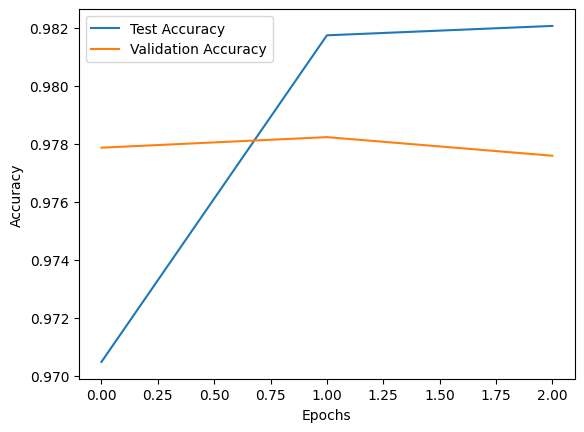

In [ ]:
plt.plot(history.history['accuracy'], label="Test Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [ ]:
df_clean.columns